In [1]:
import numpy as np 

print("NumPy version:", np.__version__)

NumPy version: 2.4.3


In [3]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "yfinance"])

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 14.3 MB/s  0:00:00 eta 0:00:01
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15635 sha256=200f2cc36d81365149b9debba1633c84356a8e81e0edf1ba93886cc6faeebc1a
  Stored in directory: /Users/mickey/Library/Caches/pip/wheels/42/d6/84/bf57a755f4569494cd00de4bb46ef064874823f4d19c82e960
Successfully built multitasking
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [yfinance]7/8 [yfinance]]]


0

In [5]:
import numpy as np
import yfinance as yf

# Pull 6 months of real HSBC data from Yahoo Finance
hsbc = yf.download("HSBA.L", period="6mo", auto_adjust=True)

# Extract closing prices as a NumPy array
prices = np.array(hsbc["Close"]).flatten()

print("Days of data:", len(prices))
print("Latest closing price: £", round(float(prices[-1]), 2))
print("Highest price: £", round(float(prices.max()), 2))
print("Lowest price: £", round(float(prices.min()), 2))

[*********************100%***********************]  1 of 1 completed

Days of data: 127
Latest closing price: £ 1177.4
Highest price: £ 1397.51
Lowest price: £ 963.89


In [6]:
# Daily percentage returns — how much did the stock move each day?
daily_returns = np.diff(prices) / prices[:-1] * 100

print("=== HSBC 6-Month Analysis ===")
print(f"Average daily return:  {round(float(daily_returns.mean()), 4)}%")
print(f"Best day:              {round(float(daily_returns.max()), 2)}%")
print(f"Worst day:             {round(float(daily_returns.min()), 2)}%")
print(f"Daily volatility:      {round(float(daily_returns.std()), 4)}%")
print(f"Annualised volatility: {round(float(daily_returns.std() * np.sqrt(252)), 2)}%")

=== HSBC 6-Month Analysis ===
Average daily return:  0.1207%
Best day:              7.94%
Worst day:             -6.02%
Daily volatility:      1.7522%
Annualised volatility: 27.82%


In [7]:
# Moving average — smooths out noise to show the trend
window = 20
moving_avg = np.convolve(prices, np.ones(window)/window, mode='valid')

print(f"Last 5 moving averages (20-day):")
for val in moving_avg[-5:]:
    print(f"  £{round(float(val), 2)}")

Last 5 moving averages (20-day):
  £1284.37
  £1281.24
  £1276.83
  £1271.36
  £1265.75


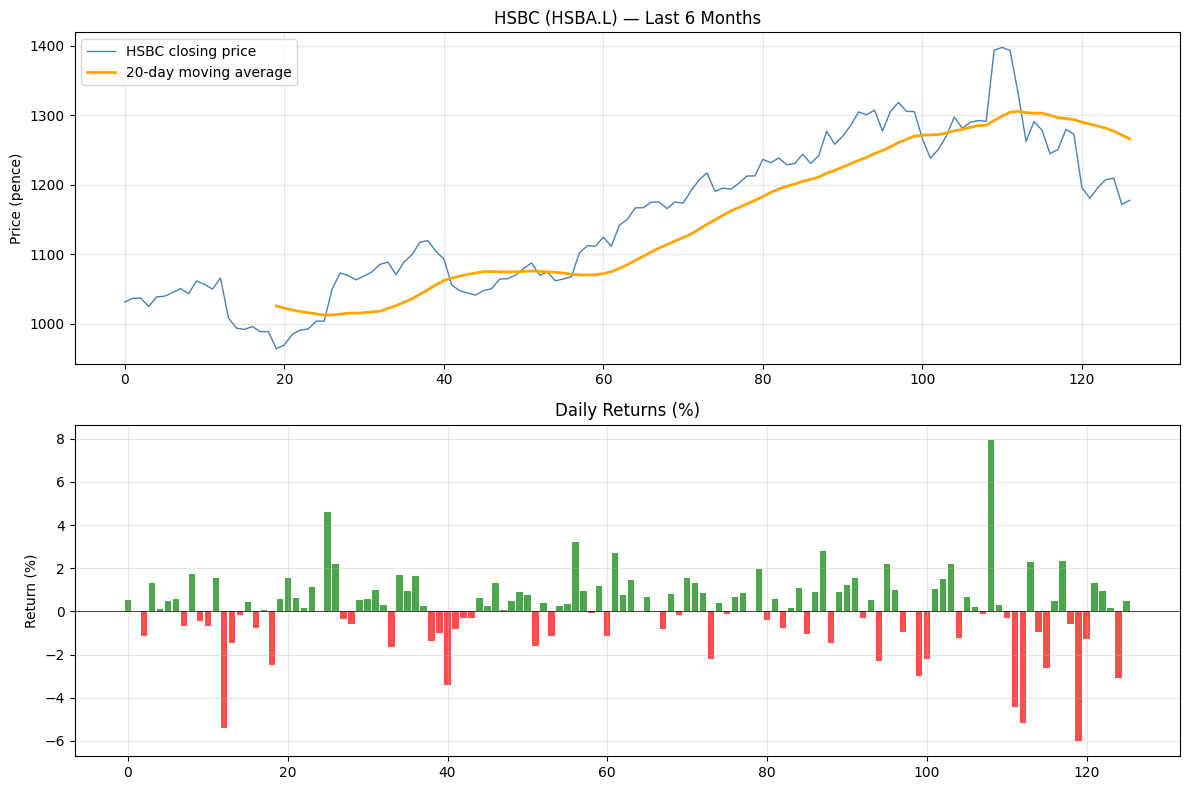

In [8]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1 — price with moving average
ax1.plot(prices, label='HSBC closing price', color='steelblue', linewidth=1)
ax1.plot(range(window-1, len(prices)), moving_avg, 
         label='20-day moving average', color='orange', linewidth=2)
ax1.set_title('HSBC (HSBA.L) — Last 6 Months')
ax1.set_ylabel('Price (pence)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2 — daily returns
ax2.bar(range(len(daily_returns)), daily_returns, 
        color=['green' if r > 0 else 'red' for r in daily_returns],
        alpha=0.7)
ax2.set_title('Daily Returns (%)')
ax2.set_ylabel('Return (%)')
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
